In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import re
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding,Dense,Dropout,Flatten
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,accuracy_score,classification_report

In [15]:
df=pd.read_csv("../data/raw/complaints_processed.csv")
df

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...
...,...,...,...
162416,162416,debt_collection,name
162417,162417,credit_card,name
162418,162418,debt_collection,name
162419,162419,credit_card,name


In [16]:
df.drop(columns='Unnamed: 0',inplace=True)

In [17]:
df.tail(10)

,product,narrative
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...
162414,debt_collection,zuntafi sent notice willing settle defaulted s...
162415,debt_collection,name
162416,debt_collection,name
162417,credit_card,name
162418,debt_collection,name
162419,credit_card,name
162420,credit_reporting,name


In [18]:
df=df[df['narrative']!='name']
df

,product,narrative
0,credit_card,purchase order day shipping amount receive pro...
1,credit_card,forwarded message date tue subject please inve...
2,retail_banking,forwarded message cc sent friday pdt subject f...
3,credit_reporting,payment history missing credit report speciali...
4,credit_reporting,payment history missing credit report made mis...
...,...,...
162410,credit_reporting,zales comenity bank closed sold account report...
162411,retail_banking,zelle suspended account without cause banking ...
162412,debt_collection,zero contact made debt supposedly resolved fou...
162413,mortgages_and_loans,zillow home loan nmls nmls actual quote provid...


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 162415 entries, 0 to 162414
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   product    162415 non-null  str  
 1   narrative  162405 non-null  str  
dtypes: str(2)
memory usage: 96.1 MB


In [20]:
df.describe(include='O')

,product,narrative
count,162415,162405
unique,5,124471
top,credit_reporting,victim identity notified collection creditor s...
freq,91178,739


In [21]:
df.duplicated().sum()

np.int64(37739)

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.isna().sum()

product      0
narrative    3
dtype: int64

In [24]:
df.dropna(subset=['narrative'],inplace=True)

In [25]:
df.reset_index(drop=True,inplace=True)

In [26]:
df['product'].unique()

<ArrowStringArray>
[        'credit_card',      'retail_banking',    'credit_reporting',
 'mortgages_and_loans',     'debt_collection']
Length: 5, dtype: str

In [27]:
df1=df['product'].value_counts()
df1

product
credit_reporting       56302
debt_collection        21116
mortgages_and_loans    18759
credit_card            15023
retail_banking         13473
Name: count, dtype: int64

Text(0.5, 1.0, 'Product Value Count')

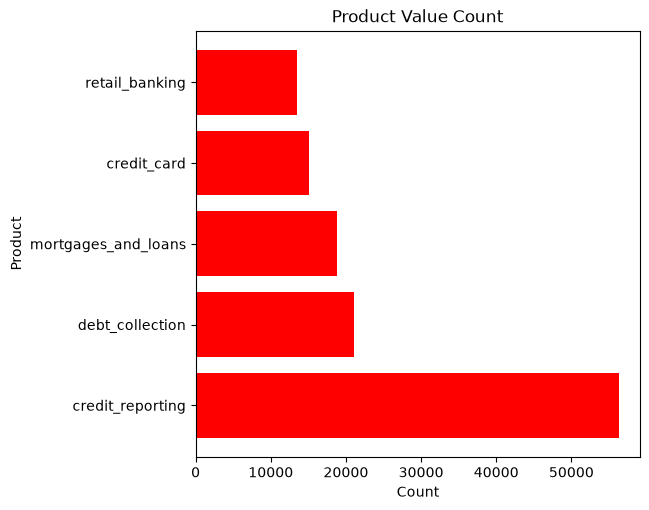

In [28]:
plt.barh(df1.index,df1.values,color='r')
plt.tight_layout()
plt.xlabel('Count')
plt.ylabel('Product')
plt.title('Product Value Count')

In [29]:
encoder=LabelEncoder()
df['product']=encoder.fit_transform(df['product'])

In [30]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'\n',' ',text)
    text=re.sub(r'\s+',' ',text)
    return text

df['narrative']=df['narrative'].apply(clean_text)

In [31]:
df

,product,narrative
0,0,purchase order day shipping amount receive pro...
1,0,forwarded message date tue subject please inve...
2,4,forwarded message cc sent friday pdt subject f...
3,1,payment history missing credit report speciali...
4,1,payment history missing credit report made mis...
...,...,...
124668,1,zales comenity bank closed sold account report...
124669,4,zelle suspended account without cause banking ...
124670,2,zero contact made debt supposedly resolved fou...
124671,3,zillow home loan nmls nmls actual quote provid...


In [32]:
x=df['narrative']
y=df['product']

In [33]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)
x_train

6213      bank huntington pandemic first began placed lo...
59605     victim identity fraud filed police report told...
19493     hello making complaint clear path lending part...
106990    first time identity compromised please remove ...
91181     please check wire transfer sent fraud induce w...
                                ...                        
31630     earned reward jcp store toward future purchase...
35251     bank america prepaid card provided edd underem...
40894     disputed erroneous information credit bureau e...
39335     separated husband since renovate apartment you...
76157     student loan lates reporting late since refina...
Name: narrative, Length: 99738, dtype: str

In [34]:
max_words=10000
max_len=200
tokenize=Tokenizer(num_words=max_words,oov_token='<OOV>')
tokenize.fit_on_texts(x_train)
x_train_seq=tokenize.texts_to_sequences(x_train)
x_test_seq=tokenize.texts_to_sequences(x_test)
x_train_pad=pad_sequences(x_train_seq,maxlen=max_len,padding='post')
x_test_pad=pad_sequences(x_test_seq,maxlen=max_len,padding='post')

In [35]:
from tensorflow.keras.layers import LSTM, Bidirectional

num_classes = y_train.nunique()
rnn = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

In [36]:
rnn.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [37]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

In [38]:
rnn.fit(x_train_pad,y_train,batch_size=32,epochs=20,validation_split=0.2, callbacks=[early_stopping])

Epoch 1/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 281s 111ms/step - accuracy: 0.7869 - loss: 0.6246 - val_accuracy: 0.8376 - val_loss: 0.4677
Epoch 2/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 291s 117ms/step - accuracy: 0.8427 - loss: 0.4718 - val_accuracy: 0.8395 - val_loss: 0.4676
Epoch 3/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 312s 125ms/step - accuracy: 0.8581 - loss: 0.4188 - val_accuracy: 0.8463 - val_loss: 0.4341
Epoch 4/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 270s 108ms/step - accuracy: 0.8721 - loss: 0.3797 - val_accuracy: 0.8506 - val_loss: 0.4309
Epoch 5/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 293s 118ms/step - accuracy: 0.8865 - loss: 0.3380 - val_accuracy: 0.8490 - val_loss: 0.4647
Epoch 6/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 289s 116ms/step - accuracy: 0.8964 - loss: 0.3028 - val_accuracy: 0.8458 - val_loss: 0.4906
Epoch 7/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 298s 120ms/step - accuracy: 0.9097 - loss: 0.2662 - val_accuracy: 0.8426 - val_loss: 0.5176
Epoch 8/20
2494/2494 ━━━━━━━━━━━━━━━━━━━━ 299s 120ms/step - ac

In [39]:
y_pred_new = np.argmax(rnn.predict(x_test_pad), axis=1)
print("New Accuracy Score:", accuracy_score(y_test, y_pred_new) * 100)
print("\nNew Classification Report:\n", classification_report(y_test, y_pred_new))

780/780 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step
New Accuracy Score: 84.80048125125326

New Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.78      3005
           1       0.86      0.92      0.89     11260
           2       0.83      0.75      0.79      4223
           3       0.86      0.81      0.83      3752
           4       0.85      0.87      0.86      2695

    accuracy                           0.85     24935
   macro avg       0.84      0.82      0.83     24935
weighted avg       0.85      0.85      0.85     24935



In [40]:
y_pred_prob=rnn.predict(x_test_pad)
y_pred_prob

780/780 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step


array([[1.7036407e-05, 9.9941945e-01, 5.1788683e-04, 4.5464367e-05,
        1.8849855e-07],
       [4.8741736e-03, 9.2355055e-01, 3.8536858e-02, 3.2610122e-02,
        4.2819889e-04],
       [6.5576672e-03, 9.8398983e-01, 9.2475768e-03, 1.8181172e-04,
        2.3134040e-05],
       ...,
       [2.0692699e-02, 9.2843390e-01, 3.6984131e-02, 1.3554263e-02,
        3.3503369e-04],
       [4.2171796e-05, 9.9819452e-01, 1.5194535e-03, 2.4233363e-04,
        1.5242390e-06],
       [3.9979905e-02, 3.4835830e-01, 5.2919203e-01, 7.5699888e-02,
        6.7698951e-03]], shape=(24935, 5), dtype=float32)

In [41]:
y_pred=np.argmax(y_pred_prob,axis=1)
y_pred

array([1, 1, 1, ..., 1, 1, 2], shape=(24935,))

In [42]:
cm=confusion_matrix(y_test,y_pred)
cm

array([[ 2291,   366,    55,    50,   243],
       [  197, 10335,   469,   210,    49],
       [  126,   747,  3150,   163,    37],
       [   64,   486,   111,  3021,    70],
       [  206,    64,    17,    60,  2348]])

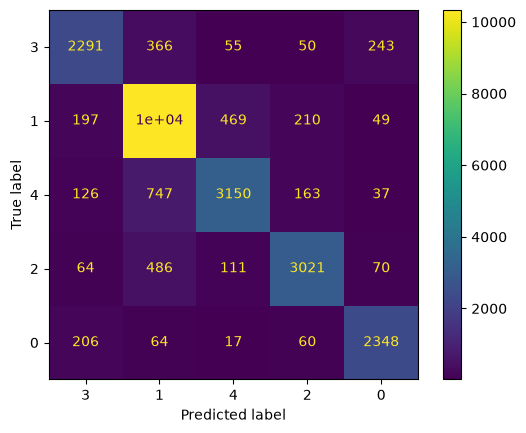

In [43]:
lab=[3,1,4,2,0]
cmd=ConfusionMatrixDisplay(cm,display_labels=lab)
cmd.plot()

In [44]:
score=accuracy_score(y_test,y_pred)*100
score

84.80048125125326

In [45]:
report=classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.79      0.76      0.78      3005
           1       0.86      0.92      0.89     11260
           2       0.83      0.75      0.79      4223
           3       0.86      0.81      0.83      3752
           4       0.85      0.87      0.86      2695

    accuracy                           0.85     24935
   macro avg       0.84      0.82      0.83     24935
weighted avg       0.85      0.85      0.85     24935



In [46]:
import joblib

# Save the trained calibrated model
joblib.dump(rnn, '../models/rnn_model.pkl')

# Save the fitted TF-IDF vectorizer
joblib.dump(Tokenizer, '../models/tokenizer.pkl')

print("Artifacts successfully saved to the models/ directory!")

Artifacts successfully saved to the models/ directory!
